In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import ttest_ind, pearsonr
from factor_analyzer import FactorAnalyzer, calculate_kmo, calculate_bartlett_sphericity
from pingouin import cronbach_alpha
plt.rcParams['font.family'] = 'Microsoft JhengHei'  # or 'Noto Sans TC'
plt.rcParams['axes.unicode_minus'] = False
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import classification_report, roc_auc_score, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.decomposition import PCA
from xgboost import XGBClassifier
import lightgbm as lgb
# import warnings
# warnings.filterwarnings("ignore", category=FutureWarning)


In [3]:
# df = pd.read_spss(r"C:\Users\User\Downloads\D00224_2\data.sav")
# df.to_csv('Dataset.csv', encoding='utf-8-sig', index=False)
df = pd.read_csv(r"C:\Users\No\Documents\GitHub\psychic-spoon\0 2025資料科學漫步\Dataset.csv")
df = df[df['rq21a'] == '答對'].reset_index(drop=True) # 篩選有效樣本中的注意力題答對的樣本
df['resist'] = np.where(df['q28_5']=='(05)沒有做過上述的抵制行為(跳答至37a題 )', 0, 1)
df.shape

(685, 212)

---
---
## 基本資料

In [6]:
# individual = df.iloc[:,4:10]
# individual['q3'] = individual['q3'].str.replace(r'^\(\d+\)', '', regex=True)
# individual['q4'] = individual['q4'].str.replace(r'^\(\d+\)', '', regex=True)

# # rename_ = {'q1':'性別', 'q2':'出生年','q3':'出生縣市', 'q4':'學歷'}
# # individual = individual.rename(columns=rename_).drop(columns=['q3_other', 'q4_88_text'])
# individual = individual.drop(columns=['q3_other', 'q4_88_text'])

# individual.info()

In [7]:
# individual['birthyear_ad'] = individual['q2']+1911
# individual['age'] = 2021-individual['birthyear_ad']
# bins = [0, 29, 44, 59, 120]
# labels = ['青年', '壯年', '中年', '老年']
# individual['age_g'] = pd.cut(individual['age'], bins=bins, labels=labels, right=True)
# def edu_group(x):
#     if x in ["國(初)中"]:
#         return "國中以下"
#     elif x in ["高職(高商、高工)", "高中職業科", "高中普通科", "軍警專修班", "軍警專科班", "二專", "三專", "五專", "空中行專"]:
#         return "高中職"
#     elif x in ["大學", "技術學院、科大", "空中大學", "軍警官校或大學"]:
#         return "大學"
#     elif x in ["碩士", "博士"]:
#         return "研究所以上"
#     else:
#         return None

# individual["edu_g"] = individual["q4"].apply(edu_group)
# individual

---
---

## 網路使用行為

In [8]:
# internet_usage = df.iloc[:,11:59]

# internet_usage['q6'] = np.round((internet_usage['q6_h'] + internet_usage['q6_m']/60), 4)
# internet_usage['q7'] = np.round((internet_usage['q7_h'] + internet_usage['q7_m']/60), 4)
# cols =  internet_usage.columns.tolist()
# i ,j = cols.index('q6_h'), cols.index('q6')
# cols[i], cols[j] = cols[j], cols[i]
# i ,j = cols.index('q6_m'), cols.index('q7')
# cols[i], cols[j] = cols[j], cols[i]
# internet_usage = internet_usage[cols].drop(columns=['q6_h', 'q6_m', 'q7_h', 'q7_m'])

# internet_usage_col_replace = {
#                         'q8_1': '(01)維繫友誼與他人保持聯絡(傳LINE、滑臉書等)',
#                         'q8_2': '(02)娛樂消遣(玩遊戲、看卡通動漫、看電影、戲劇、看直播、聽音樂、交友軟體、追星、命理占卜、打發時間、無聊)',
#                         'q8_3': '(03)獲得時事/新聞/政府資訊(搜尋關鍵字、看新聞、看政府資訊、天氣資訊)',
#                         'q8_4': '(04)獲得生活休閒資訊(美食、觀光旅遊、醫療衛生保健、家庭生活、親子婚姻關係、交通資訊)',
#                         'q8_5': '(05)理財消費購物(看理財資訊、網路購物、理財管理、繳費、財經股市)',
#                         'q8_6': '(06)學習或工作(有支薪)(語言學習、線上課程、使用文書處理軟體、學習各種軟體)',    
                        
#                         'q9_1': '(01)LINE',
#                         'q9_2': '(02)Facebook Messenger(臉書聊天室)',
#                         'q9_3': '(03)微信Wechat',
#                         'q9_4': '(04)WhatsApp',
#                         'q9_5': '(05)Hangouts',
#                         'q9_6': '(06)Skype',
#                         'q9_7': '(07)Facetime',
#                         'q9_8': '(08)Telegram',
#                         'q9_88': '(88)其他',

#                         'q10_1': '(01)臉書(Facebook)',
#                         'q10_2': '(02)Instagram',
#                         'q10_3': '(03)推特(Twitter)',
#                         'q10_4': '(04)LinkedIn',
#                         'q10_5': '(05)微博',
#                         'q10_6': '(06)噗浪(Plurk)',
#                         'q10_7': '(07)抖音(TikTok)',
#                         'q10_8': '(08)PTT',
#                         'q10_9': '(09)Dcard',
#                         'q10_10': '(10)Pinterest',
#                         'q10_88': '(88)其他',

#                         'q11_1': '(01)YouTube',
#                         'q11_2': '(02)愛奇藝',
#                         'q11_3': '(03)Netflix 網飛',
#                         'q11_4': '(04)KKTV',
#                         'q11_5': '(05)LINE TV',
#                         'q11_6': '(06)Li TV',
#                         'q11_7': '(07)Twitch',
#                         'q11_8': '(08)friDay影音',
#                         'q11_88': '(88)其他'
#                         }

# def replace_(df, col_map):
#     for col, text in col_map.items():
#         x = df[col].replace(text, 1)
#         x = x.infer_objects(copy=False)
#         x = x.fillna(0)
#         df[col] = x.astype(int)
# replace_(internet_usage, internet_usage_col_replace)

# rename_ = {'q5_1':'每週平均上網天數',
#            'q6':'一天因工作或課業上網小時','q7':'一天因其他所需上網小時',
#            'q8_1':'因維繫友誼與他人保持聯絡上網', 'q8_2':'因娛樂消遣上網', 'q8_3':'因獲得時事/新聞/政府資訊上網', 'q8_4':'因獲得生活休閒資訊上網', 'q8_5':'因理財消費購物上網', 'q8_6':'因學習或工作上網',
#            'q9_1':'最近一個月使用line', 'q9_2':'最近一個月使用Messenger(臉書聊天室)', 'q9_3':'最近一個月使用微信Wechat', 'q9_4':'最近一個月使用WhatsApp', 'q9_5':'最近一個月使用Hangouts', 'q9_6':'最近一個月使用Skype', 'q9_7':'最近一個月使用Facetime', 'q9_8':'最近一個月使用Telegram', 'q9_88':'最近一個月使用其他即時通訊軟體',
#            'q10_1':'最近一個月使用臉書(Facebook)', 'q10_2':'最近一個月使用Instagram', 'q10_3':'最近一個月使用推特(Twitter)', 'q10_4':'最近一個月使用LinkedIn', 'q10_5':'最近一個月使用微博', 'q10_6':'最近一個月使用噗浪(Plurk)', 'q10_7':'最近一個月使用抖音(TikTok)', 'q10_8':'最近一個月使用PTT', 'q10_9':'最近一個月使用Dcard', 'q10_10':'最近一個月使用Pinterest', 'q10_88':'最近一個月使用其他社群媒體',
#            'q11_1':'最近一個月使用YouTube', 'q11_2':'最近一個月使用)愛奇藝', 'q11_3':'最近一個月使用Netflix 網飛', 'q11_4':'最近一個月使用KKTV', 'q11_5':'最近一個月使用LINE TV', 'q11_6':'最近一個月使用Li TV', 'q11_7':'最近一個月使用Twitch', 'q11_8':'最近一個月使用friDay影音', 'q11_88':'最近一個月使用其他影音平台'}
# internet_usage = internet_usage.rename(columns=rename_).drop(columns=['q8_88', 'q8_88_text', 'q8_90', 'q9_88_text', 'q9_90', 'q10_88_text', 'q10_90', 'q11_88_text', 'q11_90'])
# internet_usage.info()

---
---

## 政治與公共事務參與

In [9]:
public_attend = df.iloc[:, 166:171]
times_score = {'從來沒有':1, '很少':2, '有時':3, '經常':4}
times_cols = ['q24_01_1', 'q24_02_1', 'q24_03_1', 'q24_04_1', 'q24_05_1']
for col in times_cols:
    public_attend[col] = pd.to_numeric(public_attend[col].replace(times_score))
    
# rename_ = {'q22_01_1':'多常在網路上看到別人留言髒話/不好聽的話', 'q22_02_1':'多常在網路上看別人兇激怒他的人', 'q22_03_1':'多常在網路上看到別人罵討厭他的人', 'q22_04_1':'多常在網路上看到別人開不雅玩笑', 'q22_05_1':'多常在網路上看到別人用諷刺方式回覆他人',
#            'q23_01_1':'多常在網路上留言髒話/不好聽的話', 'q23_02_1':'多常在網路上兇激怒你的人', 'q23_03_1':'多常在網路上罵討厭你的人', 'q23_04_1':'多常在網路上開不雅玩笑', 'q23_05_1':'多常在網路上用諷刺方式回覆他人'}
# internet_attack = internet_attack.rename(columns=rename_)
public_attend_cols = ['q24_01_1', 'q24_02_1', 'q24_03_1', 'q24_04_1', 'q24_05_1']

public_attend.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 685 entries, 0 to 684
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   q24_01_1  685 non-null    int64
 1   q24_02_1  685 non-null    int64
 2   q24_03_1  685 non-null    int64
 3   q24_04_1  685 non-null    int64
 4   q24_05_1  685 non-null    int64
dtypes: int64(5)
memory usage: 26.9 KB


In [10]:
def cronbach_alpha(df_items: pd.DataFrame) -> float:
    """ df_items 為 n×k 的題目得分資料框 """
    k = df_items.shape[1]                       # 題目數 k
    item_var = df_items.var(ddof=1, axis=0)     # 各題變異數 σ_i^2
    total_var = df_items.sum(axis=1).var(ddof=1)  # 總分變異數 σ_T^2
    alpha = (k / (k - 1)) * (1 - item_var.sum() / total_var)
    return alpha

public_attend['total'] = public_attend[public_attend_cols].sum(axis=1)
n_ext = int(len(public_attend)*.27)
high = public_attend.nlargest(n_ext, 'total')
low = public_attend.nsmallest(n_ext, 'total')

rows = []
alpha_full = cronbach_alpha(public_attend[public_attend_cols])

for i in public_attend_cols:
    t_stat, p_value = ttest_ind(high[i], low[i], nan_policy='omit')
    ri = public_attend[i].corr(public_attend['total'] - public_attend[i])
    alpha_del = cronbach_alpha(public_attend[[col for col in public_attend_cols if col != i]])

    rows.append([i, round(t_stat, 2), round(p_value, 4), round(ri, 4), round(alpha_del, 4)])

result = (pd.DataFrame(rows, columns=['col', 't', 'p', 'ri', 'alpha_del']).assign(flag = lambda d:
                                                                                  ((d['t']<3)&(d['p']>=.05)) |
                                                                                  (d['ri']<.30) |
                                                                                  (d['alpha_del']>alpha_full)))
print('項目分析:')
print(result)

public_attend = public_attend.drop(columns=['total', 'q24_03_1'])
public_attend_cols = ['q24_01_1', 'q24_02_1', 'q24_04_1', 'q24_05_1']

from scipy.stats import f
def alpha_ci(alpha, n, k, conf_level=.95):
    """Feldt, Woodruff & Salih (1987) CI for alpha"""
    df1 = n-1
    df2 = (n-1)*(k-1)
    alpha_half = (1-conf_level)/2

    f_lower = f.ppf(1-alpha_half, df1, df2)
    f_upper = f.ppf(alpha_half, df1, df2)

    lower = 1-((1-alpha)*f_lower)
    upper = 1-((1-alpha)*f_upper)

    return lower, upper
n, k = public_attend.shape[0], len(public_attend_cols)
ci_low, ci_up = alpha_ci(alpha_full, n, k)
print('-------------------------------------------------')
print(f'信度分析: Cronbach α = {alpha_full:.6f}  (95% CI: {ci_low:.4f} – {ci_up:.4f})')
print('-------------------------------------------------')
print('校度分析:')
from factor_analyzer import calculate_kmo, calculate_bartlett_sphericity
kmo_all, kmo_model = calculate_kmo(public_attend[public_attend_cols])
print(f'KMO = {kmo_model:.4f}')
chi2, p = calculate_bartlett_sphericity(public_attend[public_attend_cols])
print(f"Bartlett's chi2 = {chi2:.2f}, p = {p:.4f}")


項目分析:
        col      t    p      ri  alpha_del   flag
0  q24_01_1  15.40  0.0  0.3584     0.6247  False
1  q24_02_1  21.90  0.0  0.5369     0.5373  False
2  q24_03_1  17.54  0.0  0.2996     0.6576   True
3  q24_04_1  15.07  0.0  0.3447     0.6304  False
4  q24_05_1  25.14  0.0  0.5176     0.5455  False
-------------------------------------------------
信度分析: Cronbach α = 0.655085  (95% CI: 0.6109 – 0.6954)
-------------------------------------------------
校度分析:
KMO = 0.6909
Bartlett's chi2 = 390.52, p = 0.0000


因子分析:


c:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


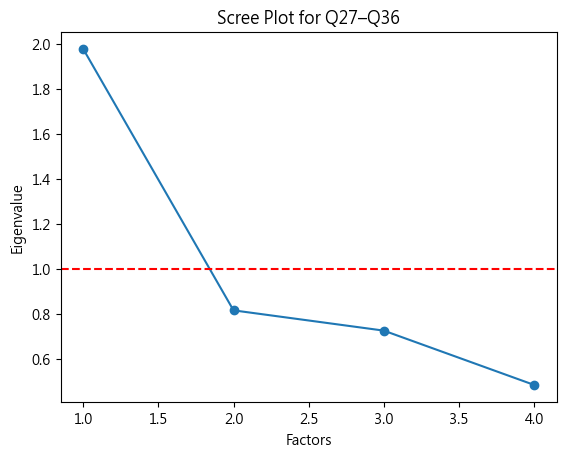

In [11]:
print("因子分析:")
data = public_attend[public_attend_cols]

# EFA
fa = FactorAnalyzer(rotation='varimax')
fa.fit(data)
ev, v = fa.get_eigenvalues()

# Scree Plot
plt.plot(range(1, len(ev)+1), ev, "o-")
plt.axhline(y=1, color="r", linestyle="--")
plt.xlabel("Factors")
plt.ylabel("Eigenvalue")
plt.title("Scree Plot for Q27–Q36")
plt.show()

---
---

## 網路攻擊行為

- 'q22_01_1':'多常在網路上看到別人留言髒話/不好聽的話'
- 'q22_02_1':'多常在網路上看別人兇激怒他的人'
- 'q22_03_1':'多常在網路上看到別人罵討厭他的人'
- 'q22_04_1':'多常在網路上看到別人開不雅玩笑'
- 'q22_05_1':'多常在網路上看到別人用諷刺方式回覆他人',
- 'q23_01_1':'多常在網路上留言髒話/不好聽的話'
- 'q23_02_1':'多常在網路上兇激怒你的人'
- 'q23_03_1':'多常在網路上罵討厭你的人'
- 'q23_04_1':'多常在網路上開不雅玩笑'
- 'q23_05_1':'多常在網路上用諷刺方式回覆他人'

In [12]:
internet_attack = df.iloc[:, 156:166]

times_score = {'從來沒有':1, '很少':2, '有時':3, '經常':4}
times_cols = ['q22_01_1', 'q22_02_1', 'q22_03_1', 'q22_04_1', 'q22_05_1',
              'q23_01_1', 'q23_02_1', 'q23_03_1', 'q23_04_1', 'q23_05_1']
for col in times_cols:
    internet_attack[col] = pd.to_numeric(internet_attack[col].replace(times_score))
    
# rename_ = {'q22_01_1':'多常在網路上看到別人留言髒話/不好聽的話', 'q22_02_1':'多常在網路上看別人兇激怒他的人', 'q22_03_1':'多常在網路上看到別人罵討厭他的人', 'q22_04_1':'多常在網路上看到別人開不雅玩笑', 'q22_05_1':'多常在網路上看到別人用諷刺方式回覆他人',
#            'q23_01_1':'多常在網路上留言髒話/不好聽的話', 'q23_02_1':'多常在網路上兇激怒你的人', 'q23_03_1':'多常在網路上罵討厭你的人', 'q23_04_1':'多常在網路上開不雅玩笑', 'q23_05_1':'多常在網路上用諷刺方式回覆他人'}
# internet_attack = internet_attack.rename(columns=rename_)
internet_attack.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 685 entries, 0 to 684
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   q22_01_1  685 non-null    int64
 1   q22_02_1  685 non-null    int64
 2   q22_03_1  685 non-null    int64
 3   q22_04_1  685 non-null    int64
 4   q22_05_1  685 non-null    int64
 5   q23_01_1  685 non-null    int64
 6   q23_02_1  685 non-null    int64
 7   q23_03_1  685 non-null    int64
 8   q23_04_1  685 non-null    int64
 9   q23_05_1  685 non-null    int64
dtypes: int64(10)
memory usage: 53.6 KB


In [13]:
def cronbach_alpha(df_items: pd.DataFrame) -> float:
    """ df_items 為 n×k 的題目得分資料框 """
    k = df_items.shape[1]                       # 題目數 k
    item_var = df_items.var(ddof=1, axis=0)     # 各題變異數 σ_i^2
    total_var = df_items.sum(axis=1).var(ddof=1)  # 總分變異數 σ_T^2
    alpha = (k / (k - 1)) * (1 - item_var.sum() / total_var)
    return alpha

internet_attack_cols = ['q22_01_1', 'q22_02_1', 'q22_03_1', 'q22_04_1', 'q22_05_1', 'q23_01_1', 'q23_02_1', 'q23_03_1', 'q23_04_1', 'q23_05_1']
internet_attack['total'] = internet_attack[internet_attack_cols].sum(axis=1)
n_ext = int(len(internet_attack)*.27)
high = internet_attack.nlargest(n_ext, 'total')
low = internet_attack.nsmallest(n_ext, 'total')

rows = []
alpha_full = cronbach_alpha(internet_attack[internet_attack_cols])

for i in internet_attack_cols:
    t_stat, p_value = ttest_ind(high[i], low[i], nan_policy='omit')
    ri = internet_attack[i].corr(internet_attack['total'] - internet_attack[i])
    alpha_del = cronbach_alpha(internet_attack[[col for col in internet_attack_cols if col != i]])

    rows.append([i, round(t_stat, 2), round(p_value, 4), round(ri, 4), round(alpha_del, 4)])

result = (pd.DataFrame(rows, columns=['col', 't', 'p', 'ri', 'alpha_del']).assign(flag = lambda d:
                                                                                  ((d['t']<3)&(d['p']>=.05)) |
                                                                                  (d['ri']<.30) |
                                                                                  (d['alpha_del']>alpha_full)))
internet_attack = internet_attack.drop(columns=['total'])
print('項目分析:')
print(result)

from scipy.stats import f
def alpha_ci(alpha, n, k, conf_level=.95):
    """Feldt, Woodruff & Salih (1987) CI for alpha"""
    df1 = n-1
    df2 = (n-1)*(k-1)
    alpha_half = (1-conf_level)/2

    f_lower = f.ppf(1-alpha_half, df1, df2)
    f_upper = f.ppf(alpha_half, df1, df2)

    lower = 1-((1-alpha)*f_lower)
    upper = 1-((1-alpha)*f_upper)

    return lower, upper
n, k = internet_attack.shape[0], len(internet_attack_cols)
ci_low, ci_up = alpha_ci(alpha_full, n, k)
print('-------------------------------------------------')
print(f'信度分析: Cronbach α = {alpha_full:.6f}  (95% CI: {ci_low:.4f} – {ci_up:.4f})')
print('-------------------------------------------------')
print('校度分析:')
from factor_analyzer import calculate_kmo, calculate_bartlett_sphericity
kmo_all, kmo_model = calculate_kmo(internet_attack[internet_attack_cols])
print(f'KMO = {kmo_model:.4f}')
chi2, p = calculate_bartlett_sphericity(internet_attack[internet_attack_cols])
print(f"Bartlett's chi2 = {chi2:.2f}, p = {p:.4f}")


項目分析:
        col      t    p      ri  alpha_del   flag
0  q22_01_1  24.92  0.0  0.6439     0.8354  False
1  q22_02_1  25.02  0.0  0.6851     0.8313  False
2  q22_03_1  26.94  0.0  0.6756     0.8322  False
3  q22_04_1  25.85  0.0  0.6318     0.8366  False
4  q22_05_1  24.84  0.0  0.6288     0.8368  False
5  q23_01_1  13.21  0.0  0.4603     0.8509  False
6  q23_02_1  13.66  0.0  0.4725     0.8500  False
7  q23_03_1  13.91  0.0  0.4904     0.8487  False
8  q23_04_1  10.96  0.0  0.4084     0.8544  False
9  q23_05_1  15.50  0.0  0.4912     0.8489  False
-------------------------------------------------
信度分析: Cronbach α = 0.856443  (95% CI: 0.8399 – 0.8720)
-------------------------------------------------
校度分析:
KMO = 0.8761
Bartlett's chi2 = 3296.55, p = 0.0000


因子分析:


c:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


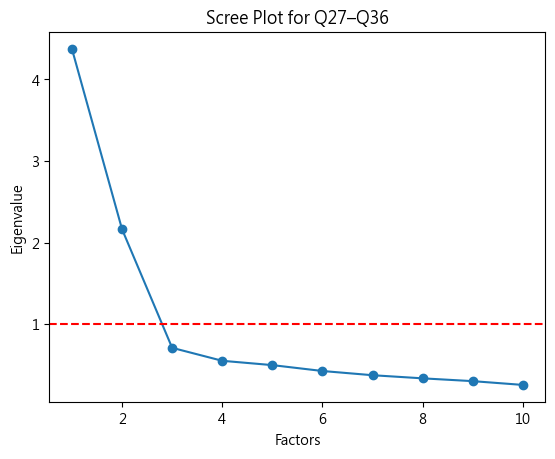

In [14]:
print("因子分析:")
data = internet_attack[internet_attack_cols]
# EFA
fa = FactorAnalyzer(rotation='varimax')
fa.fit(data)
ev, v = fa.get_eigenvalues()

# Scree Plot
plt.plot(range(1, len(ev)+1), ev, "o-")
plt.axhline(y=1, color="r", linestyle="--")
plt.xlabel("Factors")
plt.ylabel("Eigenvalue")
plt.title("Scree Plot for Q27–Q36")
plt.show()

In [15]:
fa = FactorAnalyzer(n_factors=2, rotation='varimax')
fa.fit(data)
loadings = pd.DataFrame(fa.loadings_, index=internet_attack_cols, columns=["Factor1","Factor2"])
print(loadings.round(3))

          Factor1  Factor2
q22_01_1    0.794    0.129
q22_02_1    0.832    0.155
q22_03_1    0.813    0.161
q22_04_1    0.746    0.154
q22_05_1    0.783    0.113
q23_01_1    0.157    0.643
q23_02_1    0.111    0.758
q23_03_1    0.138    0.750
q23_04_1    0.141    0.552
q23_05_1    0.170    0.693


c:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [16]:
q22 = [f"q22_{i:02d}_1" for i in range(1, 6)] 
q23 = [f"q23_{i:02d}_1" for i in range(1, 6)]  
internet_attack['net_attack_exp'] = internet_attack[q22].sum(axis=1) # 網路攻擊暴露
internet_attack['net_attack_beh'] = internet_attack[q23].sum(axis=1) # 網路攻擊行為
# internet_attack['net_attack_inx'] = internet_attack['net_attack_exp']*0.3+internet_attack['net_attack_beh']*0.7 # 網路攻擊指標
internet_attack.head(1)

,q22_01_1,q22_02_1,q22_03_1,q22_04_1,q22_05_1,q23_01_1,q23_02_1,q23_03_1,q23_04_1,q23_05_1,net_attack_exp,net_attack_beh
0,2,2,2,2,2,1,1,1,1,1,10,5


---
---

## 網路攻擊接受度

In [17]:
# internet_attack_accepted = pd.concat([df.iloc[:, 147:149], df.iloc[:, 171:175]], axis=1)
# acceptance_score = {'可以接受':5, '稍微可以接受':4, '普通':3, '有點不可以接受':2,'不可以接受':1}
# acceptance_cols = ['q20_01_1', 'q20_02_1',
#                    'q25_01_1', 'q25_02_1', 'q25_03_1', 'q25_04_1']

# for col in acceptance_cols:
#     internet_attack_accepted[col] = pd.to_numeric(internet_attack_accepted[col].replace(acceptance_score))

# rename_ = {'q20_01_1':'在網路上謾罵討厭的人使其知道他不屬於您的團體', 'q20_02_1':'為了獲得想要的而在網路上謾罵他人',
#            'q25_01_1':'在網路上對與您意見不同的人講挑釁的話', 'q25_02_1':'在網路上對討論政治話題的人講挑釁的話', 'q25_03_1':'在網路上對攻擊您看法的人謾罵', 'q25_04_1':'在網路上對與您意見不同的人謾罵'}
# internet_attack_accepted = internet_attack_accepted.rename(columns=rename_)
# internet_attack_accepted.info()

---
---

## 心理幸福感/生活品質

In [18]:
# happiness = pd.concat([df.iloc[:, 140:141], df.iloc[:, -13:-10]], axis=1)

# satisfy_score = {'非常滿意':5, '滿意':4, '普通':3, '不滿意':2,'非常不滿意':1}
# satisfy_cols = ['q15_03_1', 'q38_01_1', 'q38_02_1']
# for col in satisfy_cols:
#     happiness[col] = pd.to_numeric(happiness[col].replace(satisfy_score))

# happy_score = {'非常快樂':5, '快樂':4, '普通':3, '不快樂':2,'非常不快樂':1}
# happy_cols = ['q39_1']
# for col in happy_cols:
#     happiness[col] = pd.to_numeric(happiness[col].replace(happy_score))

# satisfysatisfy_cols = ['q15_03_1', 'q38_01_1', 'q38_02_1', 'q39_1']
# for col in satisfysatisfy_cols:
#     happiness[col] = happiness[col].fillna(happiness[col].max()).astype(int)
    
# # rename_ = {'q15_03_1':'對於政府目前處理疫情的滿意程度', 'q38_01_1':'對於生活的滿意程度',
# #            'q38_02_1':'對於目前台灣社會的滿意程度', 'q39_1':'對於目前日子的快樂程度'}
# # happiness = happiness.rename(columns=rename_)
# happiness.info()

In [19]:
# def cronbach_alpha(df_items: pd.DataFrame) -> float:
#     """ df_items 為 n×k 的題目得分資料框 """
#     k = df_items.shape[1]                       # 題目數 k
#     item_var = df_items.var(ddof=1, axis=0)     # 各題變異數 σ_i^2
#     total_var = df_items.sum(axis=1).var(ddof=1)  # 總分變異數 σ_T^2
#     alpha = (k / (k - 1)) * (1 - item_var.sum() / total_var)
#     return alpha

# happiness['total'] = happiness[satisfysatisfy_cols].sum(axis=1)
# n_ext = int(len(happiness)*.27)
# high = happiness.nlargest(n_ext, 'total')
# low = happiness.nsmallest(n_ext, 'total')

# rows = []
# alpha_full = cronbach_alpha(happiness[satisfysatisfy_cols])

# for i in satisfysatisfy_cols:
#     t_stat, p_value = ttest_ind(high[i], low[i], nan_policy='omit')
#     ri = happiness[i].corr(happiness['total'] - happiness[i])
#     alpha_del = cronbach_alpha(happiness[[col for col in satisfysatisfy_cols if col != i]])

#     rows.append([i, round(t_stat, 2), round(p_value, 4), round(ri, 4), round(alpha_del, 4)])

# result = (pd.DataFrame(rows, columns=['col', 't', 'p', 'ri', 'alpha_del']).assign(flag = lambda d:
#                                                                                   ((d['t']<3)&(d['p']>=.05)) |
#                                                                                   (d['ri']<.30) |
#                                                                                   (d['alpha_del']>alpha_full)))
# happiness = happiness.drop(columns=['total'])

# print("項目分析: ")
# print(result)

# from scipy.stats import f
# def alpha_ci(alpha, n, k, conf_level=.95):
#     """Feldt, Woodruff & Salih (1987) CI for alpha"""
#     df1 = n-1
#     df2 = (n-1)*(k-1)
#     alpha_half = (1-conf_level)/2

#     f_lower = f.ppf(1-alpha_half, df1, df2)
#     f_upper = f.ppf(alpha_half, df1, df2)

#     lower = 1-((1-alpha)*f_lower)
#     upper = 1-((1-alpha)*f_upper)

#     return lower, upper
# n, k = happiness.shape[0], len(satisfysatisfy_cols)
# ci_low, ci_up = alpha_ci(alpha_full, n, k)
# print('-------------------------------------------------')
# print(f'信度分析: Cronbach α = {alpha_full:.6f}  (95% CI: {ci_low:.4f} – {ci_up:.4f})')
# happiness = happiness.drop(columns='q15_03_1')

# print("校度分析: ")
# happiness_cols = ['q38_01_1', 'q38_02_1', 'q39_1']
# kmo_all, kmo_model = calculate_kmo(happiness[happiness_cols])
# print(f'KMO = {kmo_model:.4f}')
# chi2, p = calculate_bartlett_sphericity(happiness[['q38_01_1', 'q38_02_1', 'q39_1']])
# print(f"'Bartlett's chi2 = {chi2:.2f}, p = {p:.4f}")
# print("\n=== 因子分析 ===")
# data = happiness[happiness_cols]

# # KMO + Bartlett
# kmo_all, kmo_model = calculate_kmo(data)
# print("KMO:", round(kmo_model,3))
# chi2, p = calculate_bartlett_sphericity(data)
# print("Bartlett test: χ²=", round(chi2,2), ", p=", p)

# # EFA (先看特徵值)
# fa = FactorAnalyzer(rotation='varimax')
# fa.fit(data)
# ev, v = fa.get_eigenvalues()
# print("Eigenvalues:", ev)

# # Scree Plot
# import matplotlib.pyplot as plt
# plt.plot(range(1, len(ev)+1), ev, "o-")
# plt.axhline(y=1, color="r", linestyle="--")
# plt.xlabel("Factors")
# plt.ylabel("Eigenvalue")
# plt.title("Scree Plot for Q27–Q36")
# plt.show()

In [20]:
# happiness['happiness'] = happiness[['q38_01_1', 'q38_02_1']].sum(axis=1)
# happiness['life_qua'] = happiness['q39_1']
# # happiness['happiness_inx'] = happiness['happiness1']*0.5+happiness['q39_1']*0.5
# happiness

---
---


## 網路抵制

In [4]:
resisters = df[df['resist'] == 1].copy().reset_index(drop=True)
nonresisters = df[df['resist'] == 0].copy().reset_index(drop=True)

In [5]:
resisters.head(1)

,id,startdate,enddate,duration_in_seconds,q1,q2,q3,q3_other,q4,q4_88_text,...,q40_1,q41_1,q42_1,rq21a,rq37a,qrq2,rrq2,weight,r,resist
0,1040123,2021-06-26 10:41:56,2021-06-29 17:20:32,283115.0,男,58.0,(02)台北市,NaN,(21)博士,NaN,...,非常冰冷,90.0,獨立,答對,答對,52.0,50-59歲,0.450735,符合,1


In [15]:
cancel_culture1 = pd.concat([resisters.iloc[:, 178:179], resisters.iloc[:, 191:198]], axis=1)

def map_fill_mode(s: pd.Series, mapping: dict) -> pd.Series:
    # 先清理→映射→轉數字（未對應或雜訊變 NaN）
    x = s.astype(str).str.strip().replace(mapping)
    x = pd.to_numeric(x, errors='coerce')
    # 以眾數填補（若全是 NaN 就保留 NaN）
    m = x.mode(dropna=True)
    return x.fillna(m.iloc[0]) if not m.empty else x

want_score = {'非常不想':1, '不想':2, '普通':3, '想':4, '非常想':5}
times_score = {'從來沒有':1, '很少':2, '有時':3, '經常':4}
effect_score = {'完全沒有效':1, '沒有效':2, '普通':3, '有效':4, '非常有效':5}
serious_score = {'非常不嚴重':1, '不嚴重':2, '普通':3, '嚴重':4, '非常嚴重':5}
important_score = {'非常不重要':1, '不重要':2, '普通':3, '重要':4, '非常重要':5}
cost_score = {'非常少':1, '有點少':2, '普通':3, '有點多':4, '非常多':5}

col_maps = {
    'q27_1': want_score,
    'q30_1': effect_score,
    'q31_1': times_score,
    'q36_1': times_score,
    'q32_1': serious_score,
    'q33_1': important_score,
    'q34_1': cost_score,
    'q35_1': cost_score,
}

for c, m in col_maps.items():
    cancel_culture1[c] = map_fill_mode(cancel_culture1[c], m).astype('int')

# rename_ = {'q27_1':'多想透過社群媒體抵制言行不當的名人', 'q30_1':'使名人改善其行為而透過社群媒體抵制的效果', 'q34_1':'社群媒體抵制對您的損失', 'q35_1':'過去與您參與社群媒體抵制的人數'}
# cancel_culture = cancel_culture.rename(columns=rename_).drop(columns=['q28_4_text', 'q29_5_text'])
cancel_culture1_cols = ['q27_1', 'q30_1', 'q31_1', 'q32_1', 'q33_1', 'q34_1', 'q35_1', 'q36_1']

C:\Users\No\AppData\Local\Temp\ipykernel_30508\3269391036.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  x = s.astype(str).str.strip().replace(mapping)
C:\Users\No\AppData\Local\Temp\ipykernel_30508\3269391036.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  x = s.astype(str).str.strip().replace(mapping)
C:\Users\No\AppData\Local\Temp\ipykernel_30508\3269391036.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.in

In [16]:
import itertools

# Cronbach's alpha 函數
def cronbach_alpha(df):
    df = df.dropna(axis=0)  # 去除缺漏
    k = df.shape[1]
    if k <= 1:
        return np.nan
    variances = df.var(axis=0, ddof=1)
    total_var = df.sum(axis=1).var(ddof=1)
    return (k / (k - 1)) * (1 - variances.sum() / total_var)

cancel_culture1_cols = ['q27_1','q30_1','q31_1','q32_1','q33_1','q34_1','q35_1','q36_1']

best_alpha = -np.inf
best_subset = None

# 嘗試不同組合（至少2題）
for r in range(2, len(cancel_culture1_cols)+1):
    for subset in itertools.combinations(cancel_culture1_cols, r):
        alpha = cronbach_alpha(cancel_culture1[list(subset)])
        if alpha > best_alpha:
            best_alpha = alpha
            best_subset = subset

print("最佳組合:", best_subset)
print("最高 Cronbach’s α(信度分析):", round(best_alpha, 3))

最佳組合: ('q30_1', 'q32_1')
最高 Cronbach’s α(信度分析): 0.559


In [26]:
cancel_culture1_cols = ['q30_1', 'q32_1']
cancel_culture1 = cancel_culture1[cancel_culture1_cols]
X = cancel_culture1.apply(pd.to_numeric, errors='coerce').astype(float)
kmo_all, kmo_model = calculate_kmo(X.to_numpy())
print('效度分析:')
print(f'KMO = {kmo_model:.4f}')
chi2, p = calculate_bartlett_sphericity(X.to_numpy())
print(f"'Bartlett's chi2 = {chi2:.2f}, p = {p:.4f}")

效度分析:
KMO = 0.5000
'Bartlett's chi2 = 80.62, p = 0.0000


In [19]:
cancel_culture2 = df.iloc[:, 179:191]
cancel_culture_col_replace = {
                        'q28_1': '(01)取消關注他們的粉專或帳號',
                        'q28_2': '(02)拒絕觀看他們的發文或影音',
                        'q28_3': '(03)在網路上留言或發文指責他們',
                        
                        'q29_1': '(01)歧視特定國家、種族或性別',
                        'q29_2': '(02)有不同的政治意識型態或價值觀',
                        'q29_3': '(03)不表態支持重要的社會議題',
                        'q29_4': '(04)做出不道德、不正當或不合法行為',
                        }

def replace_(df, col_map):
    for col, text in col_map.items():
        x = df[col].replace(text, 1)
        x = x.infer_objects(copy=False)
        x = x.fillna(0)
        df[col] = x.astype(int)
replace_(cancel_culture2, cancel_culture_col_replace)

cancel_culture2_cols = ['q28_1', 'q28_2', 'q28_3', 'q29_1', 'q29_2', 'q29_3', 'q29_4']

# rename_ = {'q28_1':'取消關注他們的粉專或帳號抵制言行不當的名人', 'q28_2':'拒絕觀看他們的發文或影音抵制言行不當的名人', 'q28_3':'在網路上留言或發文指責言行不當的名人', 'q28_4':'其他抵制言行不當的名人', 'q28_5':'您沒有做過上述的抵制行為',
#            'q29_1':'因名人歧視特定國家、種族或性別而抵制名人', 'q29_2':'因有不同的政治意識型態或價值觀而抵制名人', 'q29_3':'因不表態支持重要的社會議題而抵制名人', 'q29_4':'因做出不道德、不正當或不合法行為而抵制名人', 'q29_5':'因其他而抵制名人'}
# cancel_culture = cancel_culture.rename(columns=rename_).drop(columns=['q28_4_text', 'q29_5_text'])
cancel_culture2 = cancel_culture2.drop(columns=['q28_4', 'q28_5', 'q28_4_text', 'q29_5', 'q29_5_text'])

C:\Users\No\AppData\Local\Temp\ipykernel_30508\3231658751.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  x = df[col].replace(text, 1)
C:\Users\No\AppData\Local\Temp\ipykernel_30508\3231658751.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  x = df[col].replace(text, 1)
C:\Users\No\AppData\Local\Temp\ipykernel_30508\3231658751.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-

In [20]:
print('項目分析:')
def cronbach_alpha(df_items: pd.DataFrame) -> float:
    """ df_items 為 n×k 的題目得分資料框 """
    k = df_items.shape[1]                       # 題目數 k
    item_var = df_items.var(ddof=1, axis=0)     # 各題變異數 σ_i^2
    total_var = df_items.sum(axis=1).var(ddof=1)  # 總分變異數 σ_T^2
    alpha = (k / (k - 1)) * (1 - item_var.sum() / total_var)
    return alpha

cancel_culture2['total'] = cancel_culture2[cancel_culture2_cols].sum(axis=1)
n_ext = int(len(cancel_culture2)*.27)
high = cancel_culture2.nlargest(n_ext, 'total')
low = cancel_culture2.nsmallest(n_ext, 'total')

rows = []
alpha_full = cronbach_alpha(cancel_culture2[cancel_culture2_cols])
for i in cancel_culture2_cols:
    t_stat, p_value = ttest_ind(high[i], low[i], nan_policy='omit')
    ri = cancel_culture2[i].corr(cancel_culture2['total'] - cancel_culture2[i])
    alpha_del = cronbach_alpha(cancel_culture2[[col for col in cancel_culture2_cols if col != i]])

    rows.append([i, round(t_stat, 2), round(p_value, 4), round(ri, 4), round(alpha_del, 4)])
result = (pd.DataFrame(rows, columns=['col', 't', 'p', 'ri', 'alpha_del']).assign(flag = lambda d:
                                                                                  ((d['t']<3)&(d['p']>=.05)) |
                                                                                  (d['ri']<.30) |
                                                                                  (d['alpha_del']>alpha_full)))
print(result)

cancel_culture2_cols = ['q28_1', 'q28_2', 'q29_1', 'q29_2', 'q29_4']
cancel_culture2 = cancel_culture2[cancel_culture2_cols]

print('-------------------------------------------------')
# KR-20（二元資料）
p = cancel_culture2[cancel_culture2_cols].mean()
q = 1 - p
k = len(cancel_culture2_cols)
var_total = cancel_culture2[cancel_culture2_cols].sum(axis=1).var(ddof=1)
kr20 = (k/(k-1)) * (1 - (sum(p*q)/var_total))
print("信度分析: KR-20 (Binary):", round(kr20,3))

print('-------------------------------------------------')
print('校度分析:')
X = cancel_culture2.apply(pd.to_numeric, errors='coerce').astype(float)
kmo_all, kmo_model = calculate_kmo(X.to_numpy())
print(f'KMO = {kmo_model:.4f}')
chi2, p = calculate_bartlett_sphericity(X.to_numpy())
print(f"'Bartlett's chi2 = {chi2:.2f}, p = {p:.4f}")

項目分析:
     col      t    p      ri  alpha_del   flag
0  q28_1  37.69  0.0  0.5564     0.6758  False
1  q28_2  63.45  0.0  0.6221     0.6565  False
2  q28_3   4.72  0.0  0.1177     0.7544   True
3  q29_1  34.12  0.0  0.5370     0.6813  False
4  q29_2  15.60  0.0  0.3627     0.7232  False
5  q29_3   7.24  0.0  0.2009     0.7468   True
6  q29_4  68.02  0.0  0.6473     0.6493  False
-------------------------------------------------
信度分析: KR-20 (Binary): 0.777
-------------------------------------------------
校度分析:
KMO = 0.7669
'Bartlett's chi2 = 969.83, p = 0.0000



=== 因子分析 ===


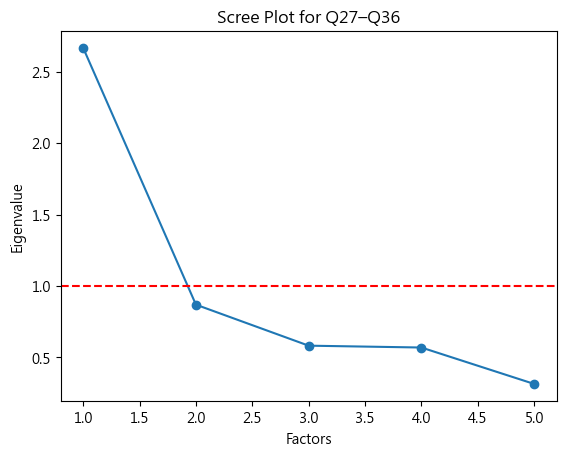

In [21]:
cancel_culture2_cols = ['q28_1', 'q28_2', 'q29_1', 'q29_2', 'q29_4']
print("\n=== 因子分析 ===")

cancel_culture2 = cancel_culture2[cancel_culture2_cols]
fa = FactorAnalyzer(rotation='varimax')
fa.fit(cancel_culture2)
ev, v = fa.get_eigenvalues()

plt.plot(range(1, len(ev)+1), ev, "o-")
plt.axhline(y=1, color="r", linestyle="--")
plt.xlabel("Factors")
plt.ylabel("Eigenvalue")
plt.title("Scree Plot for Q27–Q36")
plt.show()

In [22]:
cancel_culture = pd.concat([cancel_culture1, cancel_culture2], axis=1).reset_index(drop=True) # 抵制感知 + 抵制行為
cancel_culture

,q27_1,q30_1,q31_1,q32_1,q33_1,q34_1,q35_1,q36_1,q28_1,q28_2,q29_1,q29_2,q29_4
0,3.0,3.0,3.0,3.0,3.0,1.0,1.0,2.0,0,0,0,0,0
1,5.0,1.0,3.0,3.0,3.0,1.0,4.0,3.0,0,1,0,1,1
2,4.0,4.0,3.0,3.0,4.0,1.0,4.0,2.0,0,0,0,0,0
3,3.0,4.0,3.0,4.0,3.0,3.0,4.0,3.0,1,1,1,1,1
4,5.0,4.0,2.0,3.0,3.0,1.0,3.0,2.0,1,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
680,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,0,0,1
681,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,1,1,1
682,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,1,0,1
683,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,1,0,1


In [31]:
cancel_culture['clu_cancel_per'] = cancel_culture[cancel_culture1_cols].sum(axis=1) # 網路抵制感知
cancel_culture['clu_cancel_beh'] = cancel_culture[cancel_culture2_cols].sum(axis=1) # 網路抵制行為
# cancel_culture['clu_cancel_inx'] = cancel_culture['clu_cancel_per']*0.3+cancel_culture['clu_cancel_beh']*0.7 # 網路攻擊指標
cancel_culture

,q30_1,q32_1,q28_1,q28_2,q29_1,q29_2,q29_4,clu_cancel_per,clu_cancel_beh
0,3.0,3.0,0,0,0,0,0,6.0,0
1,1.0,3.0,0,1,0,1,1,4.0,3
2,4.0,3.0,0,0,0,0,0,7.0,0
3,4.0,4.0,1,1,1,1,1,8.0,5
4,4.0,3.0,1,1,1,0,1,7.0,4
...,...,...,...,...,...,...,...,...,...
680,NaN,NaN,1,1,0,0,1,0.0,3
681,NaN,NaN,1,1,1,1,1,0.0,5
682,NaN,NaN,0,1,1,0,1,0.0,3
683,NaN,NaN,1,1,1,0,1,0.0,4


---
---

## 政黨極化

In [32]:
political_party = df.iloc[:, -10:-8]
for col in ['q40_1', 'q41_1']:
    political_party[col]= political_party[col].replace({'非常冰冷':0, '非常溫暖':100}).astype(float)
# political_party = political_party.rename(columns={'q40_1':'國民黨溫暖程度', 'q41_1':'民進黨溫暖程度'})
# political_party.info()
political_party['q40_1']= political_party['q40_1'].replace('非常冰冷', 0)
political_party['q40_1']= political_party['q40_1'].replace('非常溫暖', 100)
political_party['q41_1']= political_party['q41_1'].replace('非常冰冷', 0)
political_party['q41_1']= political_party['q41_1'].replace('非常溫暖', 100)
political_party['q40_1']= pd.to_numeric(political_party['q40_1'])
political_party['q41_1']= pd.to_numeric(political_party['q41_1'])

t_stat, p_value = stats.ttest_rel(political_party['q40_1'], political_party['q41_1'])
different = political_party['q40_1']-political_party['q41_1']
mean_q40 = political_party['q40_1'].mean()
mean_q41 = political_party['q41_1'].mean()
mean_different = different.mean()
std_different = different.std(ddof=1)
cohen_d = mean_different/std_different if std_different != 0 else np.nan

print(f"N = {len(political_party)}")
print(f"Mean(Q40_1 國民黨溫度) = {mean_q40:.4f}")
print(f"Mean(Q41_1 民進黨溫度) = {mean_q41:.4f}")
print(f"Mean difference (Q41_1 - Q40_1) = {mean_different:.4f}")
print(f"t = {t_stat:.3f}, p = {p_value:.6f}, 小於0.05有顯著")
# print(f"Cohen's dz (paired) = {cohen_d:.4f}")

N = 685
Mean(Q40_1 國民黨溫度) = 37.0555
Mean(Q41_1 民進黨溫度) = 41.5577
Mean difference (Q41_1 - Q40_1) = -4.5022
t = -2.998, p = 0.002819, 小於0.05有顯著


           N  mean_q40  mean_q41  mean_diff
cluster                                    
0        106     68.45      9.50     -58.95
1        281     51.38     52.03       0.65
2        154      9.92     68.12      58.20
3        144     15.02     16.31       1.29


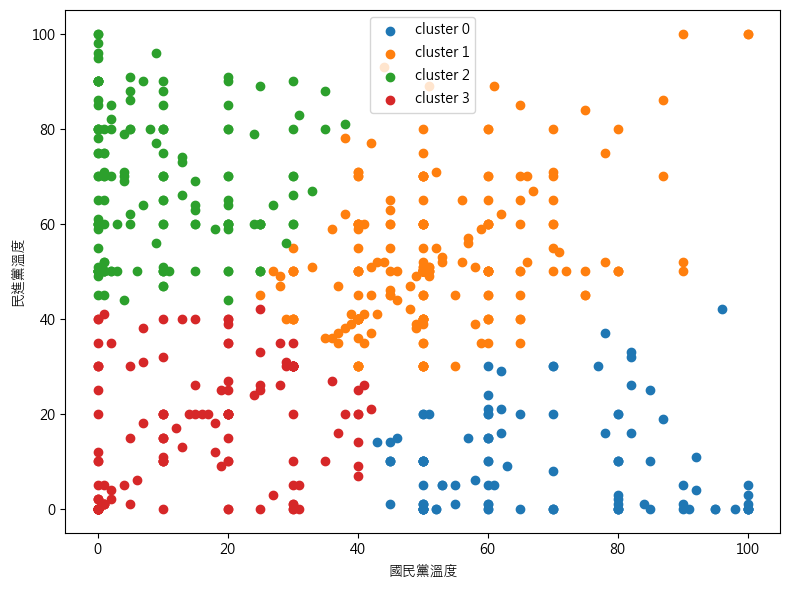

In [33]:
X = political_party.to_numpy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)
political_party = political_party.assign(cluster=labels)
cluster_summary = (political_party.groupby("cluster").agg(N=("cluster", "size"),
                                                          mean_q40=("q40_1", "mean"),
                                                          mean_q41=("q41_1", "mean"),)
                                                          .assign(mean_diff=lambda d: d["mean_q41"]-d["mean_q40"]).sort_values("cluster"))
print(cluster_summary.round(2))

plt.figure(figsize=(8, 6))
for c in range(4):
    idx = political_party["cluster"] == c
    plt.scatter(political_party.loc[idx, "q40_1"], political_party.loc[idx, "q41_1"], label=f"cluster {c}")
plt.xlabel("國民黨溫度")
plt.ylabel("民進黨溫度")
plt.legend()
plt.tight_layout()
plt.show()

mapping = dict(zip(cluster_summary.sort_values("mean_q40").index, range(4)))
political_party["cluster"] = political_party["cluster"].map(mapping)
political_party['cluster'] = political_party['cluster'].replace({0:'親綠', 1:'雙重否定', 2:'雙重認同', 3:'親藍'})


---
---


## 分析

### 信效度分析
- 題目鑑別度
- 題目與整體的概念一致性
- 題目對整體信度的貢獻（拉高還是拉低整體內部一致性）

[Cronbach alpha](https://en.wikipedia.org/wiki/Cronbach%27s_alpha)

[Confidence interval for Cronbach's Alpha](https://search.r-project.org/CRAN/refmans/cocron/html/cronbach.alpha.CI.html)

#### KMO值, Bartelett's test
- 判斷是否適合做 探索性因素分析 (EFA)／主成分分析 (PCA)

- ≥ .90 → Marvelous (極佳)
- .80–.89 → Meritorious
- .70–.79 → Middling
- .60–.69 → Mediocre
- .50–.59 → Miserable
- < .50 → Unacceptable → 不建議做 EFA（探索性因子分析）

---
---

### EDA

In [34]:
full_df = pd.concat([political_party['cluster'], internet_attack.drop(columns=['net_attack_beh', 'net_attack_exp']), public_attend, df['resist']],axis=1)

In [35]:
full_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 685 entries, 0 to 684
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   cluster   685 non-null    object
 1   q22_01_1  685 non-null    int64 
 2   q22_02_1  685 non-null    int64 
 3   q22_03_1  685 non-null    int64 
 4   q22_04_1  685 non-null    int64 
 5   q22_05_1  685 non-null    int64 
 6   q23_01_1  685 non-null    int64 
 7   q23_02_1  685 non-null    int64 
 8   q23_03_1  685 non-null    int64 
 9   q23_04_1  685 non-null    int64 
 10  q23_05_1  685 non-null    int64 
 11  q24_01_1  685 non-null    int64 
 12  q24_02_1  685 non-null    int64 
 13  q24_04_1  685 non-null    int64 
 14  q24_05_1  685 non-null    int64 
 15  resist    685 non-null    int32 
dtypes: int32(1), int64(14), object(1)
memory usage: 83.1+ KB


In [36]:
full_df.head(1)

,cluster,q22_01_1,q22_02_1,q22_03_1,q22_04_1,q22_05_1,q23_01_1,q23_02_1,q23_03_1,q23_04_1,q23_05_1,q24_01_1,q24_02_1,q24_04_1,q24_05_1,resist
0,雙重認同,2,2,2,2,2,1,1,1,1,1,2,4,3,3,0


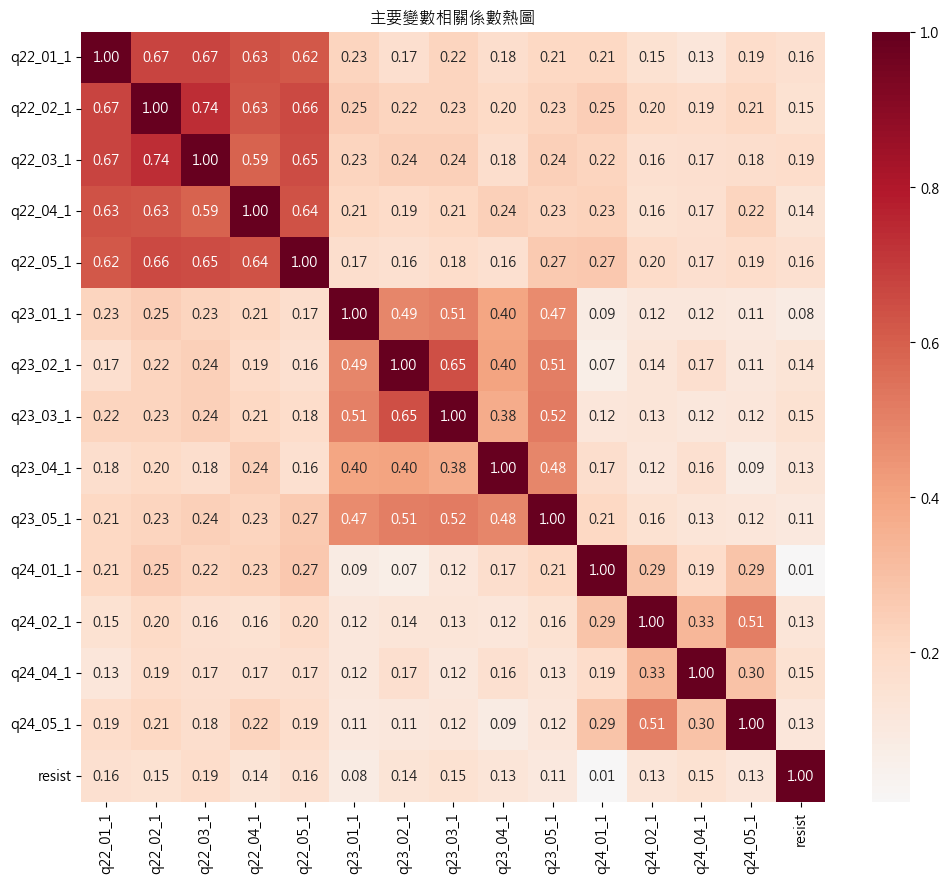

In [37]:
# corr_matrix = full_df.drop(columns=['q1', 'cluster', 'q3', 'age_g', 'edu_g']).corr(method='pearson')
corr_matrix = full_df.drop(columns=['cluster']).corr(method='pearson')

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap="RdBu_r", center=0, fmt=".2f")
plt.title("主要變數相關係數熱圖")
plt.show()

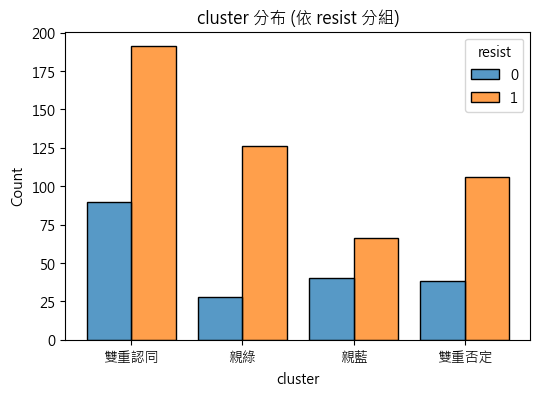

In [38]:
# cols = ["q1", "q3", 'age_g', 'edu_g', 'cluster']
cols = ['cluster']

for col in cols:
    plt.figure(figsize=(6,4))
    sns.histplot(data=full_df, x=col, hue="resist", multiple="dodge", shrink=0.8)
    plt.title(f"{col} 分布 (依 resist 分組)")
    plt.show()


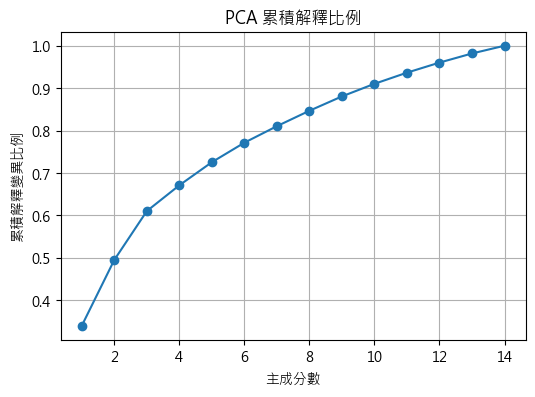

In [39]:
q22_cols = ['q22_01_1', 'q22_02_1', 'q22_03_1', 'q22_04_1', 'q22_05_1']
q23_cols = ['q23_01_1', 'q23_02_1', 'q23_03_1', 'q23_04_1', 'q23_05_1']
q24_cols = ['q24_01_1', 'q24_02_1', 'q24_04_1', 'q24_05_1']
X_features = full_df[q22_cols+q23_cols+q24_cols]
y = full_df["resist"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# 碎石圖 + 累積解釋比例
explained = pca.explained_variance_ratio_
plt.figure(figsize=(6,4))
plt.plot(range(1,len(explained)+1), explained.cumsum(), marker="o")
plt.xlabel("主成分數")
plt.ylabel("累積解釋變異比例")
plt.title("PCA 累積解釋比例")
plt.grid(True)
plt.show()

# 取前3個主成分（可依照累積解釋比例調整）
X_pca_df = pd.DataFrame(X_pca[:, :5], columns=["PC1", "PC2", "PC3", 'PC4', 'PC5'])

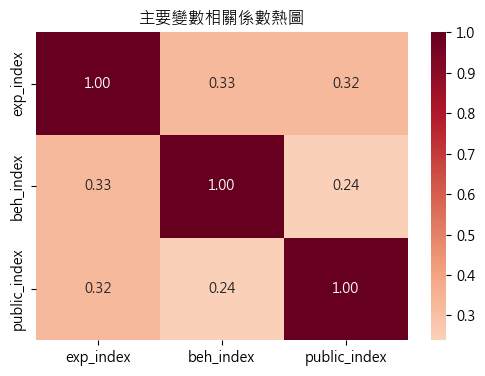

In [40]:
# 建立指數
full_df["exp_index"] = full_df[q22_cols].mean(axis=1)
full_df["beh_index"] = full_df[q23_cols].mean(axis=1)
full_df["public_index"] = full_df[q24_cols].mean(axis=1)

corr_matrix = full_df[["exp_index", "beh_index", "public_index"]].corr(method='pearson')

plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap="RdBu_r", center=0, fmt=".2f")
plt.title("主要變數相關係數熱圖")
plt.show()

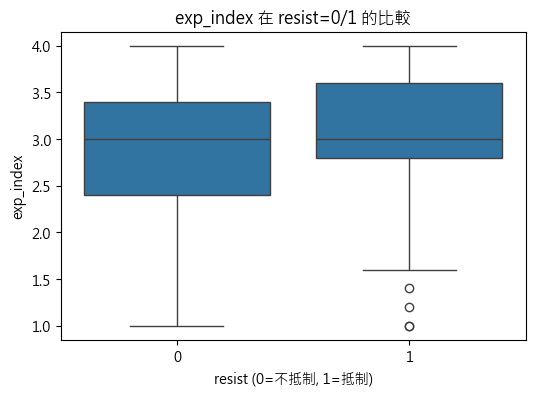

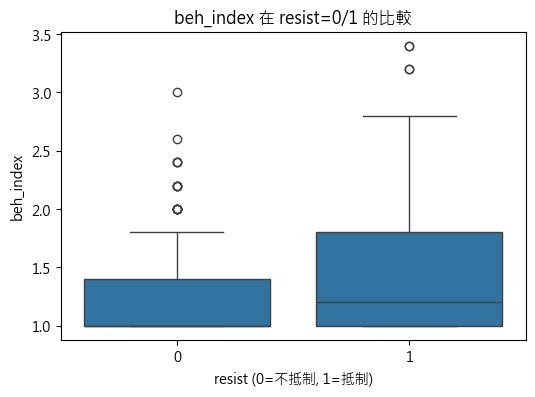

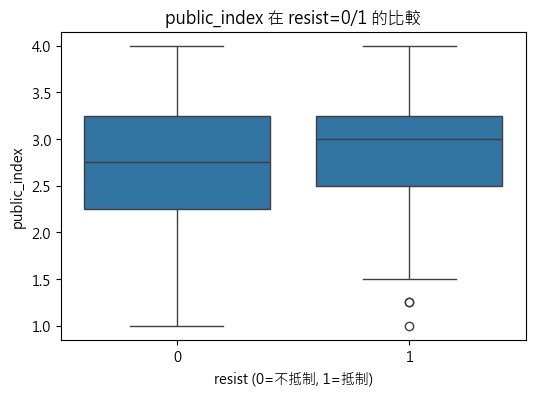

In [41]:
cols = ["exp_index", "beh_index", "public_index"]

for col in cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=full_df, x="resist", y=col)
    plt.title(f"{col} 在 resist=0/1 的比較")
    plt.xlabel("resist (0=不抵制, 1=抵制)")
    plt.ylabel(col)
    plt.show()


In [42]:
# t-test: resist=0 vs 1 在 exp_index
resist0 = full_df.loc[full_df["resist"]==0, "exp_index"]
resist1 = full_df.loc[full_df["resist"]==1, "exp_index"]
t, p = stats.ttest_ind(resist0, resist1, equal_var=False)
print("網路攻擊暴露 (exp_index) t檢定: t=%.3f, p=%.3f"%(t,p))

# 卡方檢定: cluster vs resist
contingency = pd.crosstab(full_df["cluster"], full_df["resist"])
chi2, p, dof, expected = stats.chi2_contingency(contingency)
print("政黨極化 × 媒體抵制: 卡方=%.3f, p=%.3f"%(chi2,p))


網路攻擊暴露 (exp_index) t檢定: t=-4.724, p=0.000
政黨極化 × 媒體抵制: 卡方=14.476, p=0.002


In [43]:
import statsmodels.api as sm

X = full_df[["exp_index","beh_index","public_index"]]
X = pd.concat([X, pd.get_dummies(full_df["cluster"], drop_first=True)], axis=1).astype(float)
y = full_df["resist"]

X = sm.add_constant(X)  # 加截距
logit_model = sm.Logit(y, X).fit()
print(logit_model.summary())


Optimization terminated successfully.
         Current function value: 0.565091
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                 resist   No. Observations:                  685
Model:                          Logit   Df Residuals:                      678
Method:                           MLE   Df Model:                            6
Date:                Tue, 19 Aug 2025   Pseudo R-squ.:                 0.05606
Time:                        23:53:30   Log-Likelihood:                -387.09
converged:                       True   LL-Null:                       -410.08
Covariance Type:            nonrobust   LLR p-value:                 2.991e-08
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -1.5159      0.614     -2.469      0.014      -2.719      -0.313
exp_index        0.4169

              precision    recall  f1-score   support

           0       0.38      0.59      0.46        59
           1       0.79      0.61      0.69       147

    accuracy                           0.61       206
   macro avg       0.58      0.60      0.58       206
weighted avg       0.67      0.61      0.62       206

ROC-AUC: 0.6114954456358814


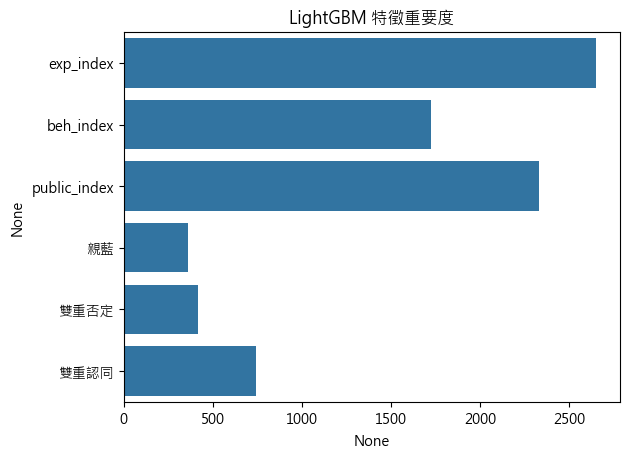

In [44]:
X = full_df[["exp_index","beh_index","public_index"]]
X = pd.concat([X, pd.get_dummies(full_df["cluster"], drop_first=True)], axis=1)
y = full_df["resist"]

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

lgb_clf = lgb.LGBMClassifier(
    n_estimators=500,
    max_depth=-1,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight="balanced",
    random_state=42, verbose=-1
)

lgb_clf.fit(X_train, y_train)
y_pred = lgb_clf.predict(X_test)
y_proba = lgb_clf.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

# 特徵重要度
import matplotlib.pyplot as plt
import seaborn as sns
feat_imp = pd.Series(lgb_clf.feature_importances_, index=X.columns)
sns.barplot(x=feat_imp, y=feat_imp.index)
plt.title("LightGBM 特徵重要度")
plt.show()


---
---